In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
file_path = 'C:/Users/thomd/My Drive (thomderuwe@gmail.com)/Thesis/Dataset/Set with desc.csv'
df = pd.read_csv(file_path)        

In [6]:
# Data overview
data = df['revenue']

n = len(data)
mean = np.mean(data)
median = np.median(data)

print('Total inputs:', n)
print('Mean:', int(np.round(mean)))
print('Minimum anual income:', int(min(data)))
print('Maximum anual income:', int(max(data)))
print('Median:', int(median))

Total inputs: 119099
Mean: 72448
Minimum anual income: 4000
Maximum anual income: 7141778
Median: 62000


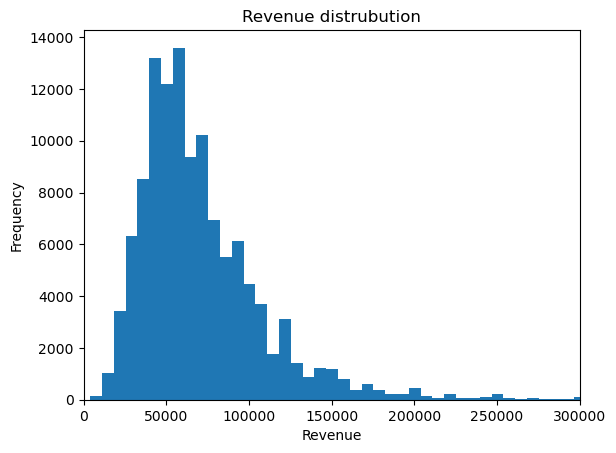

In [ ]:
# Histogram on revenue capped at 300,000
data = df['revenue']

plt.hist(data, bins=1000)
plt.xlim(0,300000)
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.title('Revenue distrubution')

plt.show()

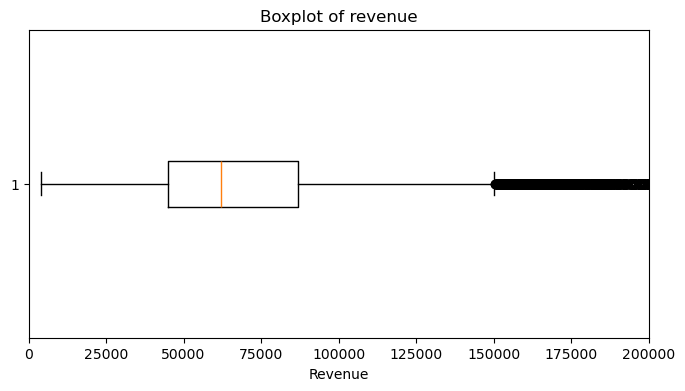

In [10]:
# Boxplot on revenue capped at 200,000
data = df['revenue']

plt.figure(figsize = (8,4))
plt.xlim(0,200000)
plt.boxplot(data, vert = False)
plt.xlabel('Revenue')
plt.title('Boxplot of revenue')
plt.show()

In [12]:
# Outlier dampening using log1p() transformation
df['revenue_log1p'] = np.log1p(df['revenue'])
df.to_csv(file_path)

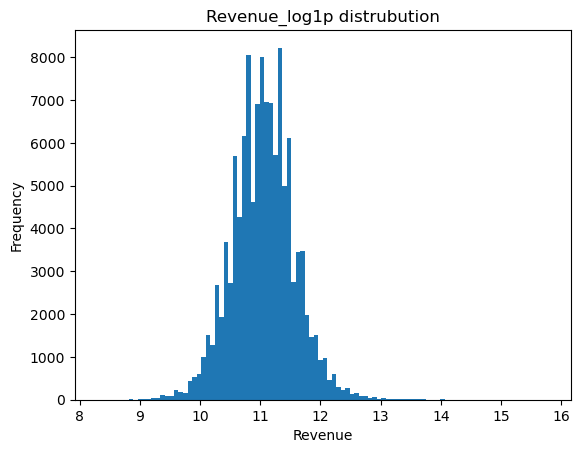

In [14]:
# Histogram on revenue_log1p
data = df['revenue_log1p']

plt.hist(data, bins=100)
# plt.xlim(9,13)
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.title('Revenue_log1p distrubution')

plt.show()

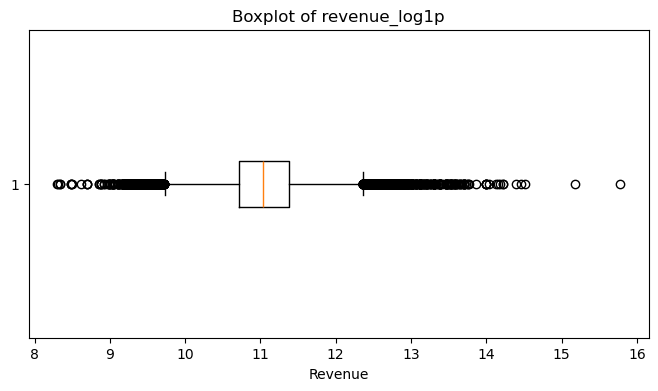

In [16]:
# Boxplot on revenue capped at 200,000
data = df['revenue_log1p']

plt.figure(figsize = (8,4))
# plt.xlim(0,200000)
plt.boxplot(data, vert = False)
plt.xlabel('Revenue')
plt.title('Boxplot of revenue_log1p')
plt.show()

In [18]:
df[['loan_amnt', 'revenue', 'revenue_log1p', 'dti_n']].describe()

,loan_amnt,revenue,revenue_log1p,dti_n
count,119099.000000,1.190990e+05,119099.000000,119099.000000
mean,13999.739083,7.244781e+04,11.049517,16.379206
std,8012.889371,5.308719e+04,0.516159,7.527059
min,1000.000000,4.000000e+03,8.294300,0.000000
25%,8000.000000,4.500000e+04,10.714440,10.780000
50%,12000.000000,6.200000e+04,11.034906,16.160000
75%,19500.000000,8.700000e+04,11.373675,21.730000
max,35000.000000,7.141778e+06,15.781472,38.570000


In [20]:
top_purposes = df['purpose'].value_counts().nlargest(10)
print(top_purposes)

purpose
debt_consolidation    68372
credit_card           25051
home_improvement       7170
other                  6360
major_purchase         3061
small_business         2518
car                    1884
wedding                1187
medical                 970
house                   805
Name: count, dtype: int64


Text(0.5, 1.0, 'Loan_amnt distrubution')

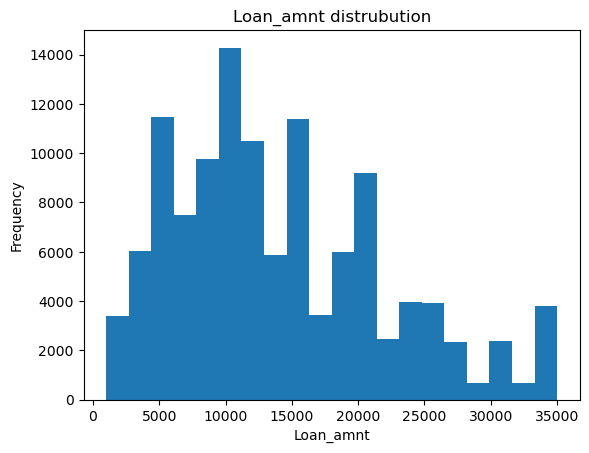

In [22]:
# Distribution loan_amnt
data = df['loan_amnt']

plt.hist(data, bins=20)
plt.xlabel('Loan_amnt')
plt.ylabel('Frequency')
plt.title('Loan_amnt distrubution')

In [ ]:
# Check if there are instances where the loan_amnt is bigger then the revenue
print(df.loc[df['loan_amnt']>df['revenue'],'id'])

Series([], Name: id, dtype: int64)


In [ ]:
# Check if a high dti_n and loan_amnt is an often occurance
dti_n_high = df['dti_n'].quantile(0.95)
loan_high = df['loan_amnt'].quantile(0.95)
high_risk_ids = df.loc[(df['loan_amnt'] >= loan_high) & (df['dti_n'] >= dti_n_high), 'id'] 
print(high_risk_ids)

175       12917941
193       13027949
413       12975920
617       12957048
961       13005887
            ...   
110158     1348576
110627     1340074
111071     1336461
111172     1334665
118777     1112461
Name: id, Length: 308, dtype: int64


In [ ]:
# Feature correlation with revenue
corr_matrix = df.select_dtypes(include = 'number').corr(method = 'spearman')

corr_revenue = (corr_matrix['revenue_log1p']
                .drop('revenue')
                .sort_values(key = abs, ascending = False))

print(corr_revenue)

revenue_log1p    1.000000
loan_amnt        0.480382
dti_n           -0.173055
fico_n           0.100976
id               0.091146
Default         -0.069458
Unnamed: 0      -0.025651
experience_c          NaN
Name: revenue_log1p, dtype: float64


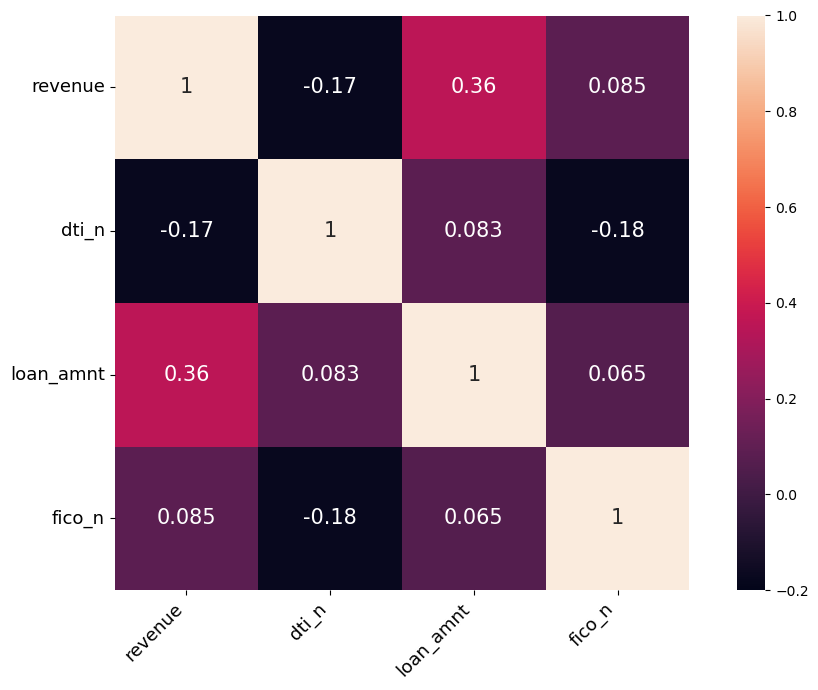

In [28]:
# Total correlation matrix
nummeric = df.select_dtypes(include = 'number')
cols_to_remove = ['experience_c', 'Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.2', 'id', 'revenue_log1p', 'Default'] 
relevant = nummeric.drop(columns = cols_to_remove).corr()


plt.figure(figsize=(10, 7))

sns.heatmap(
    relevant,
    annot=True,
    fmt=".2g",
    cmap="rocket",
    square=True,
    cbar=True,
    linewidths=0,
    vmin=-0.2,
    vmax=1,
    annot_kws={"size": 15}
)

plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(rotation=0, fontsize=13)

plt.tight_layout()
plt.show()